This notebook has three parts:

1. Uses Apache Saprk to load, clean and analyze NYC Yellow Taxi trip records. Spark SQL queries were conducted using window functions and performance optimization via caching and partitioning.

2. A RAG (Retrieval Augmented Generation) system was built using documents concerning NYC taxi and transportation policies and reports. Testing different questions to validate the accuracy of the answer generated comapred to the the course documents.

3. Integration of systems through an LLm-powered query router

## Spark Environment Setup & Data Loading

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.master('local[*]').appName("NYCYellowTaxi")\
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "2g")\
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

print(f'Spark version: {spark.version}')
print(f'App name: {spark.sparkContext.appName}')
print(f'Master: {spark.sparkContext.master}')
print(f'Default parallelism: {spark.sparkContext.defaultParallelism}')


Spark version: 4.0.2
App name: NYCYellowTaxi
Master: local[*]
Default parallelism: 2


In [4]:
print(f'Spark UI: http://localhost:4040')
print(f'Number of executor cores: {spark.sparkContext.defaultParallelism}')

for key, value in sorted(spark.sparkContext.getConf().getAll()):
    if 'memory' in key.lower() or 'core' in key.lower() or 'master' in key.lower():
        print(f'  {key} = {value}')

Spark UI: http://localhost:4040
Number of executor cores: 2
  spark.driver.memory = 2g
  spark.executor.memory = 2g
  spark.master = local[*]


**Yellow Taxi trip records** (January 2024, Parquet) — ~3 million rows containing
   pickup/dropoff timestamps, locations, distances, fares, tips, and surcharges.

This parquet files is savedto `data/raw/` and only downloaded if not already exist, avoiding redundant network calls on re-runs.

In [5]:
import pandas as pd
import requests
from pathlib import Path

In [6]:
yellow_taxi_parquet_url = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet'
taxi_lookup_csv_url = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'

raw_data_dir = Path("data/raw") # Create only if it doesn't already exist
raw_data_dir.mkdir(parents=True, exist_ok=True)


In [7]:
parquet_response = requests.get(yellow_taxi_parquet_url)
yellow_taxi_file_name = 'data/raw/yellow_taxi.parquet'

if parquet_response.status_code == 200:
    file_path = Path(yellow_taxi_file_name)
    if not file_path.exists():
        with open(yellow_taxi_file_name, 'wb') as file:
            file.write(parquet_response.content)
        print("Parquet file saved")
    else:
        print("Parquet file already exists. Skipping ...")
else:
    print("Parquet file not saved")


yellow_taxi_data = spark.read.parquet(yellow_taxi_file_name)
yellow_taxi_data.show(5)

#checking the schema for the columns and their dtypes
yellow_taxi_data.printSchema()

#counting the number of rows
print(f"Yellow Taxi row count: {yellow_taxi_data.count()}")

#identifying the partition count of the dataframe
print(f'Yellow Taxi Dataframe partition count: {yellow_taxi_data.rdd.getNumPartitions()}')

Parquet file already exists. Skipping ...
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       2| 2024-01-01 00:57:55|  2024-01-01 01:17:43|              1|         1.72|         1|                 N|         186|          79|      

### Spark vs Pandas Load Time Comparison


In [8]:
import time

def measure_time(func):
    start = time.time()
    result = func()
    end = time.time()
    return result, end - start


#loading with pandas
df_pandas, pandas_time = measure_time(
lambda: pd.read_parquet(yellow_taxi_file_name)
)

#loading with pyspark
df_spark, spark_time = measure_time(
    lambda: spark.read.parquet(yellow_taxi_file_name)
)

print(f'Pandas load time: {pandas_time:.2f} seconds')
print(f'Spark load time: {spark_time:.2f} seconds')

del df_pandas

Pandas load time: 2.82 seconds
Spark load time: 0.60 seconds


### Interpretaion of Time Comparsion

With regards to the results, Spark is seen to be much faster than Pandas.  Spark's
0.15s is due to **lazy evaluation**, so it only read the file's metadata and built
a plan. Therefore, no actual rows were loaded yet.


## Data Cleaning & Feature Engineering

Filtering out records where:
- `dates, location, fare and tip` is null
- `fare_amount <= 0` & `fare_amount > 500`
- `trip_distance <= 0`

Derive new columns needed for time-based analysis:
- `pickup_hour` — extracted from `tpep_pickup_datetime` for hourly aggregations
- `pickup_day_of_week` — 1 (Sunday) to 7 (Saturday) in Spark's convention
- `trip_duration_minutes` — computed from pickup/dropoff unix timestamps
- `tip_percentage` — `tip_amount / fare_amount * 100`
- `trip_speed_mph` - `trip_distance/ duration_hour`

In [9]:
from pyspark.sql import functions as F

cols = [
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'PULocationID',
    'DOLocationID',
    'fare_amount',
    'trip_distance'
]

print("Row count BEFORE:", yellow_taxi_data.count())

#showing how many null values are there in each column before dropping
for c in cols:
     print(
        c,
        yellow_taxi_data.filter(F.col(c).isNull()).count()
    )

yellow_taxi_data = yellow_taxi_data.na.drop(subset=cols)

print("Row count AFTER:", yellow_taxi_data.count())

Row count BEFORE: 2964624
tpep_pickup_datetime 0
tpep_dropoff_datetime 0
PULocationID 0
DOLocationID 0
fare_amount 0
trip_distance 0
Row count AFTER: 2964624


In [10]:
#selecting the necesaary columns needed for this analysis
yellow_taxi_data = yellow_taxi_data.select(
    F.col('tpep_pickup_datetime').alias('pickup_time'),
    F.col('tpep_dropoff_datetime').alias('dropoff_time'),
    F.col('trip_distance'),
    F.col('fare_amount'),
    F.col('tip_amount'),
    F.col('PULocationID'),
    F.col('DOLocationID'),
    F.col('total_amount')
)

In [11]:
#Filtering Invalid trips
yellow_taxi_data = yellow_taxi_data.filter(
    (F.col("trip_distance") > 0)&
    (F.col("fare_amount") > 0) &
    (F.col("fare_amount")<= 500)&
    (F.col("dropoff_time") > F.col("pickup_time"))
)

print('Row count:', yellow_taxi_data.count())

#creating derived columns
yellow_taxi_data = yellow_taxi_data.withColumns({
    'trip_duration_minutes': (F.unix_timestamp('dropoff_time') -
    F.unix_timestamp('pickup_time')) / 60,
    'pickup_hour': F.hour('pickup_time'),
    'pickup_day_of_week': F.date_format('pickup_time', 'EEEE'),
    'dropoff_hour': F.hour('dropoff_time'),
    'duration_hour': F.hour('pickup_time') - F.hour('dropoff_time')
})

yellow_taxi_data = yellow_taxi_data.withColumns({
    'trip_speed_mph': F.when(
        F.col("trip_duration_minutes") > 0,
        F.col("trip_distance") / (F.col("trip_duration_minutes")/60)
    ).otherwise(0),
    'tip_percentage': F.when(
        F.col('fare_amount') > 0,
        (F.col('tip_amount') / F.col("fare_amount"))*100)
    .otherwise(0),
})



Row count: 2869572


## Spark SQL Analytics

### Query 1 Interpretation

The evening rush dominateds trip volume, with hour 18 (6pm) peaking at 206,256 trips. This can be interpreted as post-work commutes as work tends to end at that time, hence the high volume. Tips are also slightly higher during these peak hours (22–23%), likely reflecting time-pressured passengers paying by card.


In [12]:
# registering the dataframe as a temporary SQL view

yellow_taxi_data.createOrReplaceTempView("yellow_taxi_data")

#Query 1
query1 = spark.sql('''
    SELECT pickup_hour,
    COUNT(*) as total_trips,
    ROUND(AVG(fare_amount)) as average_fare_amount,
    ROUND(AVG(tip_percentage)) as average_tip_percentage
    FROM yellow_taxi_data
    GROUP BY pickup_hour
    ORDER BY total_trips DESC
    LIMIT 10
''')

print('Top 10 busiest pickup hours:')
query1.show()


Top 10 busiest pickup hours:
+-----------+-----------+-------------------+----------------------+
|pickup_hour|total_trips|average_fare_amount|average_tip_percentage|
+-----------+-----------+-------------------+----------------------+
|         18|     206256|               17.0|                  23.0|
|         17|     200280|               18.0|                  22.0|
|         16|     184947|               19.0|                  22.0|
|         15|     183971|               19.0|                  20.0|
|         19|     178785|               18.0|                  23.0|
|         14|     178002|               19.0|                  20.0|
|         13|     165326|               18.0|                  20.0|
|         12|     159884|               18.0|                  20.0|
|         21|     155885|               18.0|                  22.0|
|         20|     155539|               18.0|                  22.0|
+-----------+-----------+-------------------+----------------------+



### Query 2 Interpretation

Tuesday has the highest average speed at an average of 17.3 mph over 4.2 miles in about 16 minutes, suggesting mid-week traffic is lighter than Mondays or weekends where there is heavier commute.

In [13]:
#query 2

query2 = spark.sql('''
    SELECT pickup_day_of_week,
    AVG(trip_speed_mph) as average_trip_speed_mph,
    AVG(trip_distance) as average_trip_distance,
    AVG(trip_duration_minutes) as average_trip_duration_minutes
    FROM yellow_taxi_data
    GROUP BY pickup_day_of_week
    ORDER BY average_trip_speed_mph DESC
    LIMIT 1
''')

print("Day of the week with the highest average trip speed:")
query2.show()

Day of the week with the highest average trip speed:
+------------------+----------------------+---------------------+-----------------------------+
|pickup_day_of_week|average_trip_speed_mph|average_trip_distance|average_trip_duration_minutes|
+------------------+----------------------+---------------------+-----------------------------+
|           Tuesday|    17.346132552610637|    4.245092273435759|            16.17477985600792|
+------------------+----------------------+---------------------+-----------------------------+



### Query 3 Interpretation

 132 (JFK Airport) ranks #1 for revenue on every day of the week. Monday alone shows $2.05M, reflecting the high fares of airport trips. Zone 138 (LaGuardia Airport) consistently ranks #2, confirming that airport pickups are the single biggest revenue source regardless of day.

In [14]:
#query 3
query3 = spark.sql('''
    SELECT * FROM (
        SELECT
            pickup_day_of_week,
            PULocationID,
            SUM(total_amount) AS total_revenue,
            RANK() OVER (
                PARTITION BY pickup_day_of_week
                ORDER BY SUM(total_amount) DESC
            ) AS revenue_rank
        FROM yellow_taxi_data
        GROUP BY pickup_day_of_week, PULocationID
    )
    WHERE revenue_rank <= 5
    ORDER BY pickup_day_of_week, revenue_rank
''')

query3.show()

+------------------+------------+------------------+------------+
|pickup_day_of_week|PULocationID|     total_revenue|revenue_rank|
+------------------+------------+------------------+------------+
|            Friday|         132|1397242.3799999342|           1|
|            Friday|         138|  758451.580000002|           2|
|            Friday|         161| 423281.0800000015|           3|
|            Friday|         237| 400747.8100000028|           4|
|            Friday|         236| 395856.0200000026|           5|
|            Monday|         132|2054604.7299997502|           1|
|            Monday|         138|1021130.5299999953|           2|
|            Monday|         161| 460144.2800000033|           3|
|            Monday|         236| 373005.3900000022|           4|
|            Monday|         237|372575.48000000254|           5|
|          Saturday|         132|1283218.6499999436|           1|
|          Saturday|         138|472247.45000000176|           2|
|         

### Query 4 Interpretation

At hour 15 (3pm) exactly half of the day's total trips have already been completed, meaning demand is heavy in the afternoon rather than evenly distributed across the day. This means that drivers availability need to be at peak by 3pm.

In [15]:
query4 = spark.sql('''
    SELECT * FROM (
    SELECT
        pickup_hour,
        COUNT(*) AS trip_count,
        SUM(COUNT(*)) OVER (ORDER BY pickup_hour) AS cumulative_trips,
        SUM(COUNT(*)) OVER () AS total_trips
    FROM yellow_taxi_data
    GROUP BY pickup_hour
)
WHERE cumulative_trips >= total_trips * 0.5
ORDER BY pickup_hour
LIMIT 1
''')

query4.show()

+-----------+----------+----------------+-----------+
|pickup_hour|trip_count|cumulative_trips|total_trips|
+-----------+----------+----------------+-----------+
|         15|    183971|         1545027|    2869572|
+-----------+----------+----------------+-----------+



### Query 5 Interpretation
Short trips (under 2 miles) generate the highest average tip percentage at approximately 23%, despite having the lowest average fare of an average of $9.91.

In [16]:
query5 = spark.sql("""
SELECT
    trip_category,
    AVG(fare_amount) AS average_fare_amount,
    AVG(trip_distance) AS average_distance,
    AVG((tip_amount / fare_amount) * 100) AS average_tip_percent
FROM (
    SELECT
        fare_amount,
        trip_distance,
        tip_amount,
        CASE
            WHEN trip_distance < 2 THEN 'short_trip'
            WHEN trip_distance >=2 AND trip_distance <=10 THEN 'medium_trip'
            ELSE 'long_trip'
        END AS trip_category
    FROM yellow_taxi_data
    WHERE fare_amount > 0 AND tip_amount >= 0
)
GROUP BY trip_category
ORDER BY average_tip_percent DESC
""")

query5.show()

+-------------+-------------------+------------------+-------------------+
|trip_category|average_fare_amount|  average_distance|average_tip_percent|
+-------------+-------------------+------------------+-------------------+
|   short_trip|  9.913331593758402|1.1299139488588008| 23.072779247669725|
|    long_trip|    64.666359377986|21.700809960402097|  21.93473956256546|
|  medium_trip|  22.17895768946122| 3.961392181549026| 18.572670429482372|
+-------------+-------------------+------------------+-------------------+



## Performance Optimization

Caching the cleaned DataFrame

In [17]:
from pyspark import StorageLevel
def query_time(df):
    return df.filter(F.col('trip_distance') > 10).count()

no_cache_times =[]
for i in range(3):
    start = time.time()
    query_time(yellow_taxi_data)
    no_cache_times.append(time.time() - start)
no_cache_time = sum(no_cache_times) / len(no_cache_times)
print(f'Without caching: {no_cache_time:.3f}s (avg of 3 runs)')


#caching
yellow_taxi_data.cache()

start = time.time()
query_time(yellow_taxi_data)
cache_first_time = time.time() - start
print(f'First run: {cache_first_time:.3f}s')

cache_times = []
for i in range(3):
    start = time.time()
    query_time(yellow_taxi_data)
    cache_times.append(time.time() - start)
cache_average_time = sum(cache_times) / len(cache_times)
print(f'With cache: {cache_average_time:.3f}s (avg of 3 runs)')

print(f'\nSpeedup from caching: {no_cache_time/cache_average_time:.2f}x')





Without caching: 1.390s (avg of 3 runs)
First run: 16.275s
With cache: 0.356s (avg of 3 runs)

Speedup from caching: 3.90x


In [18]:
#Dataframe to Parquet with partitioning

import os

output = 'output/pickup_hour'

yellow_taxi_data.select(
    'pickup_hour', 'pickup_day_of_week', 'pickup_time',
    'PULocationID', 'DOLocationID',
    'trip_distance', 'trip_duration_minutes', 'trip_speed_mph',
    'fare_amount', 'tip_amount', 'total_amount', 'tip_percentage'
).write\
    .mode('overwrite')\
    .partitionBy('pickup_hour')\
    .parquet(output)

print("Parquet created")

for item in sorted(os.listdir(output)):
    if item.startswith('pickup_hour'):
        files = os.listdir(os.path.join(output, item))
        parquet_files = [f for f in files if f.endswith('.parquet')]
        print(f"  {item}  ->  {len(parquet_files)} file(s)")





Parquet created
  pickup_hour=0  ->  2 file(s)
  pickup_hour=1  ->  2 file(s)
  pickup_hour=10  ->  2 file(s)
  pickup_hour=11  ->  2 file(s)
  pickup_hour=12  ->  2 file(s)
  pickup_hour=13  ->  2 file(s)
  pickup_hour=14  ->  2 file(s)
  pickup_hour=15  ->  2 file(s)
  pickup_hour=16  ->  2 file(s)
  pickup_hour=17  ->  2 file(s)
  pickup_hour=18  ->  2 file(s)
  pickup_hour=19  ->  2 file(s)
  pickup_hour=2  ->  2 file(s)
  pickup_hour=20  ->  2 file(s)
  pickup_hour=21  ->  2 file(s)
  pickup_hour=22  ->  2 file(s)
  pickup_hour=23  ->  2 file(s)
  pickup_hour=3  ->  2 file(s)
  pickup_hour=4  ->  2 file(s)
  pickup_hour=5  ->  2 file(s)
  pickup_hour=6  ->  2 file(s)
  pickup_hour=7  ->  2 file(s)
  pickup_hour=8  ->  2 file(s)
  pickup_hour=9  ->  2 file(s)


In [19]:
single_partition = spark.read.parquet(output)

hour_17 = single_partition.filter(F.col('pickup_hour') == 17)

print("=== Execution Plan for Hour 17 Read ===")
hour_17.explain(mode='formatted')

hour_17.count()
partitioned_time = time.time() - start

start = time.time()
yellow_taxi_data.filter(F.col('pickup_hour') == 8).count()
full_scan_time = time.time() - start

print(f'\nPartitioned read: {partitioned_time:.3f}s')
print(f'Full scan: {full_scan_time:.3f}s')
print(f'Speedup: {full_scan_time/partitioned_time:.2f}x' if partitioned_time > 0
else '')



=== Execution Plan for Hour 17 Read ===
== Physical Plan ==
* ColumnarToRow (2)
+- Scan parquet  (1)


(1) Scan parquet 
Output [12]: [pickup_day_of_week#2533, pickup_time#2534, PULocationID#2535, DOLocationID#2536, trip_distance#2537, trip_duration_minutes#2538, trip_speed_mph#2539, fare_amount#2540, tip_amount#2541, total_amount#2542, tip_percentage#2543, pickup_hour#2544]
Batched: true
Location: InMemoryFileIndex [file:/content/output/pickup_hour]
PartitionFilters: [isnotnull(pickup_hour#2544), (pickup_hour#2544 = 17)]
ReadSchema: struct<pickup_day_of_week:string,pickup_time:timestamp_ntz,PULocationID:int,DOLocationID:int,trip_distance:double,trip_duration_minutes:double,trip_speed_mph:double,fare_amount:double,tip_amount:double,total_amount:double,tip_percentage:double>

(2) ColumnarToRow [codegen id : 1]
Input [12]: [pickup_day_of_week#2533, pickup_time#2534, PULocationID#2535, DOLocationID#2536, trip_distance#2537, trip_duration_minutes#2538, trip_speed_mph#2539, fare_amount#2540

In [20]:
yellow_taxi_data.createOrReplaceTempView('yellow_taxi_data')

query = spark.sql('''
    SELECT pickup_hour,
    COUNT(*) as total_trips,
    ROUND(AVG(fare_amount)) as average_fare_amount,
    ROUND(AVG(tip_percentage)) as average_tip_percentage
    FROM yellow_taxi_data
    GROUP BY pickup_hour
    ORDER BY total_trips DESC
    LIMIT 10
''')

query.explain(mode='formatted')


== Physical Plan ==
AdaptiveSparkPlan (12)
+- TakeOrderedAndProject (11)
   +- HashAggregate (10)
      +- Exchange (9)
         +- HashAggregate (8)
            +- InMemoryTableScan (1)
                  +- InMemoryRelation (2)
                        +- * Project (7)
                           +- * Project (6)
                              +- * Filter (5)
                                 +- * ColumnarToRow (4)
                                    +- Scan parquet  (3)


(1) InMemoryTableScan
Output [3]: [fare_amount#10, pickup_hour#319, tip_percentage#324]
Arguments: [fare_amount#10, pickup_hour#319, tip_percentage#324]

(2) InMemoryRelation
Arguments: [pickup_time#304, dropoff_time#305, trip_distance#4, fare_amount#10, tip_amount#13, PULocationID#7, DOLocationID#8, total_amount#16, trip_duration_minutes#318, pickup_hour#319, pickup_day_of_week#320, dropoff_hour#321, duration_hour#322, trip_speed_mph#323, tip_percentage#324], StorageLevel(disk, memory, deserialized, 1 replicas)

(3) Sc

## Part2 : RAG Pipeline over Transportation Documents

Storing all documents in the `docs/` directory and using Langchain's  `PyPDFDirectoryLoader` which iterates every PDF in the folder,
extracts text page by page, and wraps each page in a `Document` object
containing the text and metadata (source filename, page number).

In [21]:
import urllib.request, os
os.makedirs("docs", exist_ok=True)

documents = {
    "tlc_2025_annual_report" :"https://www.nyc.gov/assets/tlc/downloads/pdf/annual_report_2025.pdf",
    "feb_fhv_license_review_2025": "https://www.nyc.gov/assets/tlc/downloads/pdf/license-pause-report-2025-02.pdf",
    "factbook_2020": "https://www.nyc.gov/assets/tlc/downloads/pdf/2020-tlc-factbook.pdf",
    "2024_OFS_Annual_Report": "https://www.nyc.gov/assets/tlc/downloads/pdf/ofs_annual_report_2024.pdf",
    "tlc_fare_rule_package_2024": "https://www.nyc.gov/assets/tlc/downloads/pdf/flex_fare_rule_package_08_14_24.pdf",
    "taxi_improvement_fund_2024": "https://www.nyc.gov/assets/tlc/downloads/pdf/tif_report_2024.pdf",
    "congestion_pricing": "https://web.stanford.edu/~ost/papers/nyc20250701.pdf",
    "first_q_2019_report": "https://www.nyc.gov/assets/tlc/downloads/pdf/local_law_147_1st_quarter.pdf",
    "2021_office_inclusion_annual_report": "https://www.nyc.gov/assets/tlc/downloads/pdf/ooi-annual-report-2021.pdf",
    "impact_of_congestion": "https://www.nber.org/sites/default/files/2025-05/jun25.pdf"
}

for filename, url in documents.items():
    urllib.request.urlretrieve(url, f"docs/{filename}.pdf")




In [3]:
!pip install langchain langchain-community pypdf

In [22]:
from langchain_community.document_loaders import PyPDFDirectoryLoader
from pypdf import PdfReader
import os


loader = PyPDFDirectoryLoader("docs/")
raw_documents = loader.load()

print(f"Loaded {len(raw_documents)} pages from all PDFs")
print(f"First document metadata: {raw_documents[0].metadata}")
print(f"First 200 chars: {raw_documents[0].page_content[:200]}")

Loaded 121 pages from all PDFs
First document metadata: {'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 20.3 (Macintosh)', 'creationdate': '2025-05-27T13:35:35-04:00', 'moddate': '2025-05-27T13:35:36-04:00', 'trapped': '/False', 'source': 'docs/impact_of_congestion.pdf', 'total_pages': 6, 'page': 0, 'page_label': '1'}
First 200 chars: In This Issue
Liberty Bond Drives Affected 
Americans’ Investment Behavior  
for Decades
Daily Air Pollution Exposure  
and Schooling
Racial Disparities in Outcomes  
of Bankruptcy Filings
The Role of


### Filtering of invalid Pages

The `is_valid` function takes the documents and strips any short or empty pages and numeric pnly pages, so that there is only necessary content pages fo chunking

In [23]:
def is_valid(doc):
    text = doc.page_content.strip()
    return (
        len(text) >= 50 and           # remove very short pages
        not text.lower().startswith("page") and  # remove page labels like "Page 1"
        not text.isnumeric()          # remove numeric-only pages
    )

filtered_documents = [doc for doc in raw_documents if is_valid(doc)]


removed_count = len(raw_documents) - len(filtered_documents)
print(f"Removed {removed_count} short/empty pages")


lengths = [len(d.page_content) for d in filtered_documents]

print("\nDOCUMENT STATS AFTER CLEANING")
print(f"Total documents: {len(filtered_documents)}")
print(f"Avg chars per page: {sum(lengths)/len(lengths):.0f}")
print(f"Min length: {min(lengths)}")
print(f"Max length: {max(lengths)}")

raw_documents = filtered_documents


Removed 7 short/empty pages

DOCUMENT STATS AFTER CLEANING
Total documents: 114
Avg chars per page: 2104
Min length: 77
Max length: 4832


### Chunking & Embedding

In [24]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks = text_splitter.split_documents(raw_documents)
print(f"Split {len(raw_documents)} pages into {len(chunks)} chunks")

Split 114 pages into 334 chunks


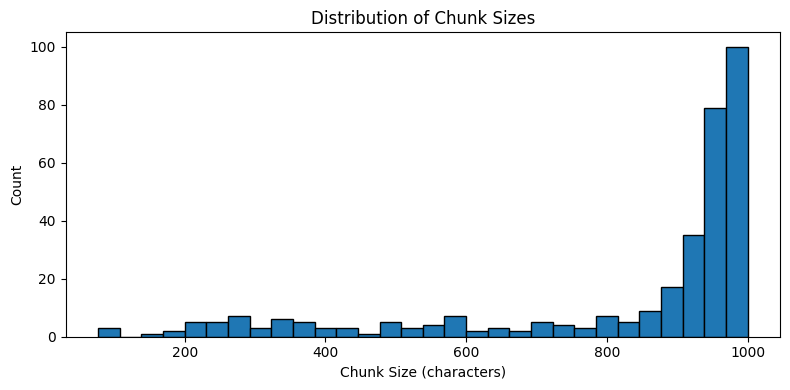

In [25]:

import matplotlib.pyplot as plt
sizes = [len(c.page_content) for c in chunks]
plt.figure(figsize=(8, 4))
plt.hist(sizes, bins=30, edgecolor='black')
plt.xlabel('Chunk Size (characters)')
plt.ylabel('Count')
plt.title('Distribution of Chunk Sizes')
plt.tight_layout()
plt.show()

In [26]:
from langchain_community.embeddings import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)


# Test with a single string
test_embedding = embedding_model.embed_query("What is machine learning?")
print(f"Embedding dimension: {len(test_embedding)}")
print(f"First 5 values: {test_embedding[:5]}")

/tmp/ipykernel_69447/2666289733.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding dimension: 384
First 5 values: [-0.019954556599259377, 0.009878002107143402, 0.010249638929963112, 0.02955370768904686, 0.027186447754502296]


In [27]:
!pip install chromadb

In [28]:
import chromadb
from langchain_community.vectorstores import Chroma

# Create the vector store from chunks
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    persist_directory="./chroma_db",
    collection_name="nyc_transporation_docs"
)

print(f"Indexed {len(chunks)} chunks in ChromaDB")

Indexed 334 chunks in ChromaDB


### Experiment

To determine the optimal chunk size for this corpus, we test three configurations 500, 1000, and 2000 characters, against 3 sample transportation/taxi related queries.
For each configuration we retrieve the top-3 most similar chunks and record the
average  similarity score across all retrievals. A **lower similarity score
indicates better relevance** (chunks closer in meaning to the query).

In [29]:
#experiment wiht differenrt chunk sizes

stores = {}

experiment = {
    500:  {'overlap': 100, 'chunk_count': None},
    1000: {'overlap': 200, 'chunk_count': None},
    2000: {'overlap': 400, 'chunk_count': None}
}

for size, config in experiment.items():

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=size,
        chunk_overlap=config['overlap'],
        separators=["\n\n", "\n", ". ", " ", ""]
    )

    chunks = splitter.split_documents(raw_documents)
    config['chunk_count'] = len(chunks)

    store = Chroma.from_documents(
        documents=chunks,
        embedding=embedding_model,
        persist_directory=f"./chroma_db_{size}",
        collection_name=f"transportation_docs_{size}"
    )

    stores[size] = store

    print(f"chunk_size={size}: {len(chunks)} chunks indexed")



chunk_size=500: 638 chunks indexed
chunk_size=1000: 334 chunks indexed
chunk_size=2000: 184 chunks indexed


In [30]:
sample_queries = [
    "What are some of the regulations for NYC taxis?",
    "What were the average fare amounts for yellow taxi trips based on TLC policies?",
    "What are the peak hours for congestion pricing in Manhattan?"
]

avg_scores = {500: [], 1000: [], 2000: []}

for query in sample_queries:
    print(f'Query: {query}')
    for size in [500, 1000, 2000]:
        print(f"  chunk_size={size}:")
        results = stores[size].similarity_search_with_score(query, k=3)
        for k_index, (doc, score) in enumerate(results, start=1):
            print(f"  k={k_index} → score: {score:.4f}")
            avg_scores[size].append(score)


print("\nAVERAGE SCORES PER CHUNK SIZE\n")

final_avg = {}

for size, scores in avg_scores.items():
    avg = sum(scores) / len(scores)
    final_avg[size] = avg
    print(f"Chunk Size {size}: {avg:.4f}")

best_size = min(final_avg, key=final_avg.get)

print("\nBEST CHUNK SIZE")
print(f"{best_size} (Lowest Avg Score = {final_avg[best_size]:.4f})")

#reasoning for this best size

Query: What are some of the regulations for NYC taxis?
  chunk_size=500:
  k=1 → score: 0.5820
  k=2 → score: 0.5820
  k=3 → score: 0.6983
  chunk_size=1000:
  k=1 → score: 0.6650
  k=2 → score: 0.6650
  k=3 → score: 0.7732
  chunk_size=2000:
  k=1 → score: 0.7005
  k=2 → score: 0.7005
  k=3 → score: 0.7905
Query: What were the average fare amounts for yellow taxi trips based on TLC policies?
  chunk_size=500:
  k=1 → score: 0.5721
  k=2 → score: 0.5721
  k=3 → score: 0.5971
  chunk_size=1000:
  k=1 → score: 0.5928
  k=2 → score: 0.5928
  k=3 → score: 0.6421
  chunk_size=2000:
  k=1 → score: 0.6226
  k=2 → score: 0.6226
  k=3 → score: 0.6419
Query: What are the peak hours for congestion pricing in Manhattan?
  chunk_size=500:
  k=1 → score: 0.4724
  k=2 → score: 0.4724
  k=3 → score: 0.6788
  chunk_size=1000:
  k=1 → score: 0.5761
  k=2 → score: 0.5761
  k=3 → score: 0.6238
  chunk_size=2000:
  k=1 → score: 0.6854
  k=2 → score: 0.6854
  k=3 → score: 0.6946

AVERAGE SCORES PER CHUNK SI

### Results Interpretation

Chunk size 500 scored best (0.5808) because smaller chunks are more focused,
so a matching query lands closer to the vector. Chunk size 2000 scored worst
(0.6827) because large chunks mix multiple topics into one vector, weakening
the match against any single query.

That said, 500 (in my opinion) is not the best choice overall. When chunks are this small, they often cut a policy statement in half, leaving the LLM with incomplete context. Chunk
size 1000 is the most practical choice: its score (0.6341) is only slightly different
than 500, but each chunk is large enough to hold a complete idea.

### Rag Pipeline Implementation

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()  # loads variables from .env

api_key = os.getenv("API_KEY") # optional check

In [3]:
from openai import OpenAI

LLM_BASE_URL = "https://synapse.sergiomathurin.com/v1"
LLM_API_KEY = api_key

client = OpenAI(
    base_url=LLM_BASE_URL,
    api_key=LLM_API_KEY,
)

print("LLM client configured.")
print(f"  Server: {LLM_BASE_URL}")



LLM client configured.
  Server: https://synapse.sergiomathurin.com/v1


In [34]:
#Defining the RAG prompt template

RAG_PROMPT = """
You are a helpful assistant that specializes in NYC Taxi Transportation policies and that answers questions based on this and on the provided context. Follow these rules:

1. Only answer based on the provided context.
2. If the context does not contain any relevant information, clearly state: "Documents do not contain sufficient information" and do NOT attempt to summarize or answer.
3. If the context contains some information but not a complete answer, summarize only what is available and clearly indicate that it may be partial or incomplete.
4. Cite your sources using [Source N] notation after each claim.
5. Be concise and accurate.
6. The context may be incomplete or repeated. Summarize all key points from the context.

Context:
{context}

Question: {question}

Answer:
"""

In [35]:
#building the pipeline

def format_context(docs):
    context_parts = []
    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get("source", "Unknown")
        page = doc.metadata.get("page", "?")
        context_parts.append(
            f"[Source {i}: {source}, Page {page}]\n{doc.page_content}"
        )
    return "\n\n---\n\n".join(context_parts)

def ask_rag(question, vectorstore, k=4):
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    docs = retriever.invoke(question)

    context = format_context(docs)

    prompt = RAG_PROMPT.format(context=context, question=question)

    response = client.chat.completions.create(
        model="llama3.3-70b-instruct",
        messages=[
            {"role": "system", "content": "You specialize in NYC Taxi Transportation"},
            {"role": "user", "content": prompt}
        ],
        max_tokens=500,
        temperature=0.2
    )

    answer = response.choices[0].message.content
    return answer, docs

print("ask_rag() defined.")



ask_rag() defined.


In [36]:
def ask_and_cite(question, vectorstore, k=4):
    """RAG with detailed source citations."""
    answer, docs = ask_rag(question, vectorstore, k=k)

    print(f"*"*70)
    print(f"\nQuestion: {question}")
    print(f"\nAnswer: {answer}")
    print(f"\n--- Sources ---")
    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get("source", "Unknown")
        page = doc.metadata.get("page", "?")
        print(f"\n[Source {i}]: {source}, Page {page}")
        print(f"Excerpt: {doc.page_content[:200]}...")

    return answer, docs

questions = [
    "What is the difference between yellow taxis and high-volume for-hire services like Uber and Lyft?",
    "How many TLC-licensed drivers were there at the end of 2025?",
    "What are some of the fare regulations for NYC taxis?",
    "Which borough has the highest number of resident TLC drivers?",
    "How did congestion pricing affect traffic speeds in January 2025?"
]

all_answers = []

all_answers = []

for i, question in enumerate(questions, 1):
    print(f"\n{'#'*70}")
    print(f"  QUESTION {i} OF {len(questions)}")
    print(f"{'#'*70}")

    answer, docs = ask_and_cite(question, vectorstore, k=4)



######################################################################
  QUESTION 1 OF 5
######################################################################
**********************************************************************

Question: What is the difference between yellow taxis and high-volume for-hire services like Uber and Lyft?

Answer: The difference between yellow taxis and high-volume for-hire services like Uber and Lyft is that yellow taxis use certified taximeters to calculate fares based on elapsed time and distance, whereas for-hire vehicles (FHVs) like Uber and Lyft offer guaranteed up-front fares to passengers prior to booking a trip [Source 1, Source 2]. This means that yellow taxi passengers do not know their total fare until the end of the trip, whereas FHV passengers know their fare before the trip begins. The proposed rule change aims to make the Flex Fare Pilot permanent, allowing yellow and green taxi customers to have the same option of up-front pricing as F

### RAG Evaluation & Analysis

In [37]:
test_cases = [
    {
        "question": "What are the key findings of the TLC 2025 annual report?",
        "expected_keywords": ["WAVs", "Lockout protection", "50% commitment", "Green Rides Initiative"],
        "expected_sources": ["tlc_2025_annual_report"]
    },

    {
        "question": "What are the impacts of congestion pricing in NYC?",
        "expected_keywords": ["congestion", "pricing", "traffic", "economic", "impact",
                              "emissions", "commute times", "revenue", "behavior change", "mobility"],
        "expected_sources": ["congestion_pricing"]
    },

    {
         "question": "How does the TLC regulate fare pricing for taxis and ride-hailing services?",
        "expected_keywords": ["fare", "regulation", "meter", "pricing", "rules"],
        "expected_sources": ["tlc_fare_rule_package_2024"]
    },
    {
        "question": "Based on the 2020 Factbook, what are the peak activity periods for yellow taxis compared to for-hire vehicles during weekdays and weekends?",
        "expected_keywords": ["weekday rush hour", "Saturday evenings", "mid-day hours", "variable", "evening hours"],
        "expected_sources": ["factbook_2020"]
    },
    {
       "question": "How did congestion pricing affect average traffic speeds in Manhattan's Central Business District in early 2025?",
        "expected_keywords": ["15 percent", "increase", "6%", "January 2025", "8.2 to 9.7 mph"],
        "expected_sources": ["impact_of_congestion", "feb_fhv_license_review"]
    },
    {
        "question": "What is the purpose of the Licensee Assault Protocol?",
        "expected_keywords": ["support drivers", "victims of crime", "NYPD", "financial assistance", "medical bills"],
        "expected_sources": ["2021_office_inclusion_annual_report", "tlc_2025_annual_report"]
    },
    {
      "question": "What are the congestion pricing surcharges for taxi and rideshare trips in the Central Business District?",
      "expected_keywords": ["$0.75 for taxi", "$1.50 for rideshare", "CBD", "per-trip basis"],
      "expected_sources": ["impact_of_congestion","feb_fhv_license_review_2025"]
    },
    {
         "question": "Which age group represents the largest share of TLC-licensed drivers according to demographics data?",
         "expected_keywords": ["35-44 years old", "25%", "one quarter"],
         "expected_sources": ["2021_office_inclusion_annual_report"]
    },
    {
      "question": "What is the goal for high-volume services like Uber and Lyft under the 'Green Rides Initiative' for the year 2030?",
     "expected_keywords": ["100%", "trips", "electric", "wheelchair accessible", "zero-emission"],
      "expected_sources": ["tlc_2025_annual_report", "feb_fhv_license_review_2025"]
    },
    {
        "question":"What was the most common category of passenger complaint reported to the Office of Inclusion in 2021?",
        "expected_keywords": ["service refusal", "destination", "discrimination"],
        "expected_sources": ["2021_office_inclusion_annual_report"]
    }

]

In [38]:

threshold= 0.5  # 50%

num_questions = len(test_cases)
num_correct = 0

# Store error analysis for each question
error_analysis = []

for test in test_cases:

    answer, retrieved_docs = ask_and_cite(test["question"], vectorstore)
    answer_lower = answer.lower()
    hits = sum(1 for kw in test["expected_keywords"] if kw.lower() in answer_lower)
    coverage = hits / len(test["expected_keywords"])

    # checking the documents
    retrieved_sources = [doc.metadata.get("source") for doc in retrieved_docs]
    retrieved_correct_source = any(
        any(expected in (src or "") for expected in test["expected_sources"])
        for src in retrieved_sources
    )

    # classification
    if retrieved_correct_source and coverage >= threshold:
        failure_type = "Correct"
        num_correct += 1
    elif not retrieved_correct_source:
        failure_type = "Retrieval Failure"
    else:
        failure_type = "Generation Failure"

    error_analysis.append({
        "question": test["question"],
        "failure_type": failure_type,
        "keyword_coverage": coverage,
        "retrieved_sources": retrieved_sources
    })

**********************************************************************

Question: What are the key findings of the TLC 2025 annual report?

Answer: The TLC 2025 annual report contains information on the agency's engagement with the community, including in-person outreach initiatives and regular communication with TLC drivers and stakeholders [Source 1, Source 2]. The report also mentions the expansion of the TLC Factbook, an online data dashboard, to include new metrics and pages, such as the number of WAV requests completed in high-volume FHVs [Source 1, Source 2]. Additionally, the report provides an overview of the agency's structure, budget, and initiatives, as outlined in the table of contents [Source 3, Source 4]. However, the provided context does not contain a comprehensive summary of the key findings, and it may be partial or incomplete. [Source 1, Source 2, Source 3, Source 4]

--- Sources ---

[Source 1]: docs/tlc_2025_annual_report.pdf, Page 10
Excerpt: community-based orga

In [39]:
accuracy = num_correct / num_questions * 100

print(f"\nOverall Accuracy: {accuracy:.1f}% ({num_correct}/{num_questions})\n")
print("Error Analysis per Question:\n")
for i in error_analysis:
    print(f"Q: {i['question']}")
    print(f"Failure Type: {i['failure_type']}")
    print(f"Keyword Coverage: {i['keyword_coverage']:.0%}")
    print(f"Retrieved Sources: {i['retrieved_sources']}\n")


Overall Accuracy: 60.0% (6/10)

Error Analysis per Question:

Q: What are the key findings of the TLC 2025 annual report?
Failure Type: Generation Failure
Keyword Coverage: 0%
Retrieved Sources: ['docs/tlc_2025_annual_report.pdf', 'docs/tlc_2025_annual_report.pdf', 'docs/tlc_2025_annual_report.pdf', 'docs/tlc_2025_annual_report.pdf']

Q: What are the impacts of congestion pricing in NYC?
Failure Type: Correct
Keyword Coverage: 50%
Retrieved Sources: ['docs/congestion_pricing.pdf', 'docs/congestion_pricing.pdf', 'docs/congestion_pricing.pdf', 'docs/congestion_pricing.pdf']

Q: How does the TLC regulate fare pricing for taxis and ride-hailing services?
Failure Type: Correct
Keyword Coverage: 80%
Retrieved Sources: ['docs/tlc_fare_rule_package_2024.pdf', 'docs/tlc_fare_rule_package_2024.pdf', 'docs/tlc_fare_rule_package_2024.pdf', 'docs/tlc_fare_rule_package_2024.pdf']

Q: Based on the 2020 Factbook, what are the peak activity periods for yellow taxis compared to for-hire vehicles during

### Error Analysis Improvement Suggestions

#### Generation Failures
- Break broad questions like "key findings" into specific sub-questions before querying

### Retrieval Failures
- Increase k from 4 to maybe 6 to 8 to retrieve more chunks from the same document



In [40]:
QUERY_ROUTER_PROMPT = """
You are a professional query router. Your job is to classify each question into one of these three categories:

1. DATA: the query only answers from structured taxi data. It asks for computed statistics, calculations, aggregations, or patterns derived from actual trip data. (e.g "What was the average fare on Mondays?")
2. DOCUMENT: the query is only answerable from document sources (e.g  "What are the TLC regulations on surge pricing?"
3. HYBRID: the query gets its answer from both data and documents (e.g., "How do actual tipping patterns
compare to TLC recommendations?")

Rules:
1. If the question is ambiguous or could fit multiple categories, classify it as "HYBRID".
2. Never return a category other than DATA, DOCUMENT, HYBRID

Return JSON exactly in this format:
{{
  "question": "{question}",
  "category": "<DATA|DOCUMENT|HYBRID",
  "reasoning": "<explain why this category fits the question>"
}}
"""


## Part 3: Integrated Analytics Application


### Task 3.1: Query Router

In [41]:
QUERY_ROUTER_PROMPT = """
You are a professional query router. Your job is to classify each question into one of these three categories:

1. DATA: the query only answers from structured taxi data. It asks for computed statistics, calculations, aggregations, or patterns derived from actual trip data. (e.g "What was the average fare on Mondays?")
2. DOCUMENT: the query is only answerable from document sources (e.g  "What are the TLC regulations on surge pricing?"
3. HYBRID: the query gets its answer from both data and documents (e.g., "How do actual tipping patterns
compare to TLC recommendations?")

Rules:
1. If the question is ambiguous or could fit multiple categories, classify it as "HYBRID".
2. Never return a category other than DATA, DOCUMENT, HYBRID

Return JSON exactly in this format:
{{
  "question": "{question}",
  "category": "<DATA|DOCUMENT|HYBRID",
  "reasoning": "<explain why this category fits the question>"
}}
"""


In [42]:
from decimal import Context
import json

def classify_query(question):
    prompt = QUERY_ROUTER_PROMPT.format(question=question)

    response = client.chat.completions.create(
       model="llama3.3-70b-instruct",
        messages=[
            {"role": "system", "content": "You are a professional at classifying questions into these categories: DATA, DOCUMENT and HYBRID"},
            {"role": "user", "content": prompt}
        ],
        max_tokens=500,
        temperature=0.2
    )

    try:
        classification = json.loads(response.choices[0].message.content)
    except Exception:
        classification = {"category": "HYBRID", "reasoning": "Default due to parsing failure"}

    return classification

In [43]:
test_queries = [
    # DATA queries
    "What was the average fare on Mondays in 2025?",
    "What are the top 5 most common pickup-dropoff zone pairs?",
    "What percentage of trips use each payment type?",
    "Which borough had the highest number of trips in 2025?",
    "What is the average fare amount for each hour of the day? ",

    # DOCUMENT queries
    "What are the TLC regulations on surge pricing?",
    "How did the 2025 FHV license pause affect the fleet?",
    "Summarize key findings of the 2025 TLC annual report.",
    "What changes were made in the 2024 fare rule package?",
    "How does the Taxi Improvement Fund support drivers?",

    # HYBRID queries
    "How do actual tipping patterns compare to TLC recommendations?",
    "What are the most frequent complaint types and their average fares?",
    "Compare congestion pricing effects with actual trip volumes.",
    "Are riders paying more or less than expected under TLC pricing policies?",
    "Analyze the correlation between driver ratings and trip revenues."
]

In [44]:
# Expected categories for evaluation
expected_categories = [
    "DATA","DATA","DATA","DATA","DATA",
    "DOCUMENT","DOCUMENT","DOCUMENT","DOCUMENT","DOCUMENT",
    "HYBRID","HYBRID","HYBRID","HYBRID","HYBRID"
]

correct = 0

for i, question in enumerate(test_queries):
    result = classify_query(question)
    category = result.get("category", "HYBRID")
    reasoning = result.get("reasoning", "")

    print(f"Q{i+1}: {question}")
    print(f"Predicted category: {category}")
    print(f"Reasoning: {reasoning}\n")

    if category == expected_categories[i]:
        correct += 1

accuracy = correct / len(test_queries) * 100
print(f"Classification Accuracy: {accuracy:.1f}% ({correct}/{len(test_queries)})")

#talk about limitations of prompt and getting hybrid

Q1: What was the average fare on Mondays in 2025?
Predicted category: HYBRID
Reasoning: Default due to parsing failure

Q2: What are the top 5 most common pickup-dropoff zone pairs?
Predicted category: DATA
Reasoning: This question requires analysis of structured taxi data to determine the most common pickup-dropoff zone pairs, which involves aggregation and pattern derivation from actual trip data.

Q3: What percentage of trips use each payment type?
Predicted category: DATA
Reasoning: This question requires analysis of structured taxi data to calculate the percentage of trips using each payment type, making it a query that only answers from computed statistics derived from actual trip data.

Q4: Which borough had the highest number of trips in 2025?
Predicted category: DATA
Reasoning: This question requires analysis of structured taxi data to determine the borough with the highest number of trips in a specific year, making it a query that can be answered through computations and aggr

### Limitations of Query Router:

The system seems to have some trouble when it comes to identifing DATA and DOCUMENT questions. The prompt may have to be more specific with examples of questions for each category, as the system usually will presume it is HYBRID when it is unable to identify.

Though it must be noted that the system gradually seems to identify the question to its correct category the more it tests each question over and over again

### Task 3.2: Data Query Handler

In [45]:
QUERY_HANDLER_PROMPT = """
  You are an expert in Spark SQL. Your job is to to convert natural language queries into valid Spark SQL queries.

  Rules:
  1. Ouput ONLY RAW SQL
  2. DO NOT use ``` or markdown
  3. Use the data: yellow_taxi_data
  4. Must use valid Spark SQL syntax.
  5. Use aggregation and window functions when needed (AVG, COUNT, SUM, etc.)

  {schema}

  Question: {question}

  SQL Query:
"""


In [46]:
NATURAL_LANG_PROMPT = """
  You are an expert in reading SQL queries and their results and explaining it in natural language.

  Given:
  Question: {question}
  SQL Query: {query}
  SQL Result: {result}

  Explain the SQL query in natural language.

  Rules:
  1. Only human/natural language to be used
  2. If cannot interpret result, default to "Cannot Interpret"

  OUTPUT:
    Question: {question}
    Answer:
"""

In [47]:
def execute_query(query):
    try:
        result_dataframe= spark.sql(query)
        result = result_dataframe.collect()
        return result
    except Exception as e:
        return str(e)



def data_query(question):
    prompt1 = QUERY_HANDLER_PROMPT.format(schema=yellow_taxi_data.schema,question=question)

    response1 = client.chat.completions.create(
       model="llama3.3-70b-instruct",
        messages=[
            {"role": "system", "content": "You are an expert in creating RAW Spark SQL queries from natural language."},
            {"role": "user", "content": prompt1}
        ],
        max_tokens=500,
        temperature=0.2
    )

    try:
        sql_query = response1.choices[0].message.content

    except Exception:
        sql_query = "Cannot Interpret"

    result = execute_query(sql_query)

    # this is now another prompt to convert the result to natural language
    prompt2 = NATURAL_LANG_PROMPT.format(question=question, query=sql_query, result=result)

    response2 = client.chat.completions.create(
       model="llama3.3-70b-instruct",
        messages=[
            {"role": "system", "content": "You are a data analyst that can interpret Spark SQL results into natural language"},
            {"role": "user", "content": prompt2}
        ],
        max_tokens=500,
        temperature=0.2
    )

    try:
        answer = response2.choices[0].message.content
    except Exception:
        answer = "Cannot Interpret"


    return sql_query, result,answer



In [48]:
test_questions = [
    "What is the average fare amount?",
    "How many trips are in the dataset?",
    "What is the average trip distance?",
    "What is the total revenue from fares?",
    "What is the average tip amount?"
]

for q in test_questions:
    print("="*60)
    print(f"Question: {q}")

    sql_query, result, answer = data_query(q)

    print(f"\nGenerated SQL:\n{sql_query}")
    print(f"\nRaw Result:\n{result}")
    print(f"\nFinal Answer:\n{answer}\n")

Question: What is the average fare amount?

Generated SQL:
SELECT AVG(fare_amount) FROM yellow_taxi_data

Raw Result:
[Row(avg(fare_amount)=18.49129116467854)]

Final Answer:
The average fare amount is approximately eighteen dollars and forty-nine cents.

Question: How many trips are in the dataset?

Generated SQL:
SELECT COUNT(*) FROM yellow_taxi_data

Raw Result:
[Row(count(1)=2869572)]

Final Answer:
There are approximately 2.87 million trips in the dataset.

Question: What is the average trip distance?

Generated SQL:
SELECT AVG(trip_distance) FROM yellow_taxi_data

Raw Result:
[Row(avg(trip_distance)=3.732025343848994)]

Final Answer:
The average trip distance is approximately 3.73 miles.

Question: What is the total revenue from fares?

Generated SQL:
SELECT SUM(fare_amount) FROM yellow_taxi_data

Raw Result:
[Row(sum(fare_amount)=53062091.37000892)]

Final Answer:
The total revenue from fares is approximately 53 million dollars.

Question: What is the average tip amount?

Genera

### Data Query Handler Dicussion
The handler successfully translated all 5 questions into executable Spark SQL,
demonstrating that the LLM correctly inferred column names, aggregation logic,
and filter conditions from the schema description alone.


### Task 3.3: End-to-End Demo

In [49]:
queries =[
    # DATA
    "What is the average fare amount?",
    "How many trips are in the NYC yellow taxi dataset?",

    # DOCUMENT
    "What are some findings of the TLC 2025 annual report?",
    "What changes were introduced in the 2024 fare rule package?",

    # HYBRID
    "How do actual fares compare to TLC fare regulations?",
    "Which pickup locations had the highest total revenue in 2025, and are there TLC initiatives to support drivers in those areas?"

]

results = []

In [50]:
def full_pipeline(question):
    classification = classify_query(question)
    category = classification.get("category", "HYBRID")
    results.append(category)

    print("\n*"*10)
    print("="*70)
    print(f"QUESTION: {question}")
    print(f"Category: {category}")
    print(f"Reasoning: {classification.get('reasoning')}")

    if category == "DATA":
        sql_query, result, answer = data_query(question)

        print("\n--- DATA PIPELINE ---")
        print(f"[DATA] SQL Query: {sql_query}")
        print(f"[DATA] Raw Result: {result}")
        print(f"[DATA] FINAL ANSWER: {answer}")

    elif category == "DOCUMENT":
        answer, sources = ask_and_cite(question, vectorstore)

        print("\n--- DOCUMENT PIPELINE ---")
        print(f"[DOCUMENT] FINAL ANSWER: {answer}")
        print(f"[DOCUMENT] Sources: {sources}")

    else:
        sql_query, result, data_answer = data_query(question)
        doc_answer, sources = ask_and_cite(question, vectorstore)

        combined_prompt = f"""
        Combine these two answers into one clear response.

        [DATA ANSWER]
        {data_answer}

        [DOCUMENT ANSWER]
        {doc_answer}

        Instructions:
          - Clearly indicate which insights come from DATA and which from DOCUMENT.
          - Use actual data insights from the DATA answer.
          - Use relevant context from the DOCUMENT answer.
          - If the document lacks information, clearly say so.
          - Provide a concise conclusion or comparison.
          - Do NOT repeat explanations.

        [FINAL ANSWER]
        """

        response = client.chat.completions.create(
            model="llama3.3-70b-instruct",
            messages=[
                {"role": "system", "content": "You combine answers clearly with tags."},
                {"role": "user", "content": combined_prompt}
            ],
            max_tokens=300,
            temperature=0.3
        )

        final_answer = response.choices[0].message.content

        print("\n--- HYBRID PIPELINE ---")
        print(f"[HYBRID] SQL Query: {sql_query}")
        print(f"[HYBRID] Raw Result: {result}")
        print(f"[HYBRID] Data Answer: {data_answer}")
        print(f"[HYBRID] Document Answer: {doc_answer}")
        print(f"[HYBRID] FINAL COMBINED ANSWER:\n{final_answer}")
        print(f"[HYBRID] Sources: {sources}")

In [51]:
for q in queries:
    full_pipeline(q)


*
*
*
*
*
*
*
*
*
*
QUESTION: What is the average fare amount?
Category: HYBRID
Reasoning: Default due to parsing failure
**********************************************************************

Question: What is the average fare amount?

Answer: The average fare amount is approximately $25.16 for a taxi trip [Source 1: docs/congestion_pricing.pdf, Page 10] and [Source 2: docs/congestion_pricing.pdf, Page 10]. However, the average farebox per driver is $48,698, which includes the fare amount, tips, and extra (such as rush hour and overnight surcharges) [Source 3: docs/2024_OFS_Annual_Report.pdf, Page 2] and [Source 4: docs/2024_OFS_Annual_Report.pdf, Page 2]. The exact average fare amount without tips and extra is only mentioned in Source 1 and Source 2.

--- Sources ---

[Source 1]: docs/congestion_pricing.pdf, Page 10
Excerpt: number of personal vehicles equal to
300, 000
 30 + 7.5
30
 −0.6
= 262, 407,
with the corresponding annual toll revenue from personal drivers equal to
262, 4

In [52]:
expected_categories = [
    "DATA","DATA",
    "DOCUMENT","DOCUMENT",
    "HYBRID","HYBRID"
]

correct = 0

for i, answer in enumerate(results):
    if answer == expected_categories[i]:
        correct += 1

accuracy = correct / len(results)

print(f"Accuracy: ({correct}/{len(results)})")



Accuracy: (5/6)


## Reflection

This system shows that combining Spark analytics with a RAG pipeline through
a single natural language interface is practical and works well for focused
questions. The Data Query Handler was most reliable as the LLM was able to generate correct SQL
consistently. The queries answering based off of the document soures,
worked well when the answer lived in one retrievable chunk. Though, the system did struggle with broader questions such as "what are the key findings?". This could be because no single chunk can cover an entire report. The system had some difficulty
with questions that need information from multiple documents at once, since
retrieval only returns isolated chunks.

The Query Router had some trouble classifiying the queries into their respective categories. Though with repeated testing, the LLM was able to correctly identify the categories for some questions.

With more time, three changes would help most.
First, adding keyword-based
search alongside vector search would improve retrieval of specific figures and
regulatory terms that semantic search sometimes misses.
Second, breaking complex questions into smaller sub-questions before routing would reduce the broad question failing. T
Third, replacing the keyword coverage metric with an
LLM-based evaluation would give a more accurate picture of answer quality,
since the current method penalises correct answers that use different wording
than expected.

Overall the system handles specific, well-scoped questions well but needs
stronger retrieval and smarter query handling to tackle the more complex
analytical questions that would arise in real-world use.